Nature Run と観測を生成中...
DA感度実験を開始します (CPUで実行中... しばらくお待ちください)...


C:\Users\hanha\AppData\Local\Temp\ipykernel_1964\1373200849.py:19: RuntimeWarning: overflow encountered in multiply
  return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F
C:\Users\hanha\AppData\Local\Temp\ipykernel_1964\1373200849.py:19: RuntimeWarning: invalid value encountered in subtract
  return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F
C:\Users\hanha\AppData\Local\Temp\ipykernel_1964\1373200849.py:25: RuntimeWarning: invalid value encountered in add
  k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
C:\Users\hanha\AppData\Local\Temp\ipykernel_1964\1373200849.py:28: RuntimeWarning: invalid value encountered in add
  x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
C:\Users\hanha\AppData\Local\Temp\ipykernel_1964\1373200849.py:35: RuntimeWarning: invalid value encountered in subtract
  M_mat = (X_pert_fwd - x_base_fwd[:, None]) / kappa


  Obs=20 完了
  Obs=25 完了


C:\Users\hanha\AppData\Local\Temp\ipykernel_1964\1373200849.py:108: RuntimeWarning: overflow encountered in matmul
  P_b = (1.0 + delta) * (M_mat @ P_a @ M_mat.T)
C:\Users\hanha\AppData\Local\Temp\ipykernel_1964\1373200849.py:109: RuntimeWarning: invalid value encountered in add
  P_b = (P_b + P_b.T) / 2.0
C:\Users\hanha\AppData\Local\Temp\ipykernel_1964\1373200849.py:113: RuntimeWarning: invalid value encountered in matmul
  x_a = x_b + K @ (y_o - H_mat @ x_b)


  Obs=30 完了
  Obs=35 完了
  Obs=40 完了
全実験完了！ (総実行時間: 55.9 秒)


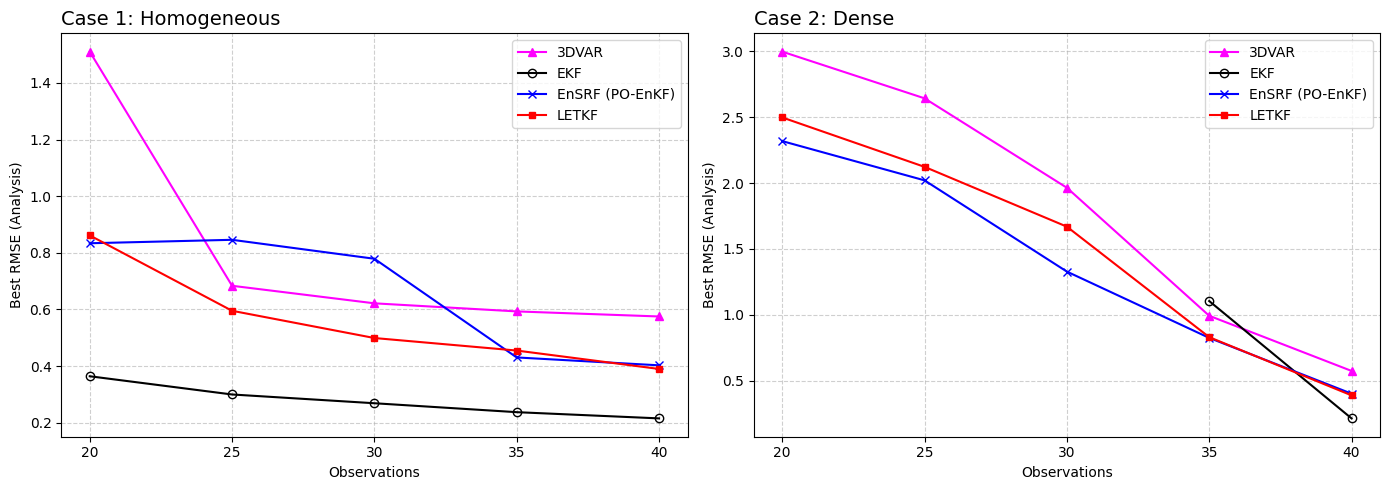

In [9]:
# =====================================================================
# 観測ネットワーク感度比較: 3DVAR / EKF / PO-EnKF / LETKF (発散修正版)
# =====================================================================
import time
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 基本パラメータ設定 ---
N = 40
F = 8.0
dt = 0.01
sampling_interval = 5   
m = 8                   
steps_spin_up = 730     
total_cycles = 1500     

# --- 2. CPU用 モデル・局所化関数 ---
def lorenz96(x, F):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M_fast(x_in, dt, steps):
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

def M_jacob_fast(x_in, dt, steps, kappa=1e-5):
    X_pert = x_in[:, None] + np.eye(N) * kappa
    x_base_fwd = M_fast(x_in, dt, steps)
    X_pert_fwd = M_fast(X_pert, dt, steps)
    M_mat = (X_pert_fwd - x_base_fwd[:, None]) / kappa
    return M_mat

def Gaspari_Cohn_L(sigma, obs_indices):
    P = len(obs_indices)
    i = np.arange(N)[:, None]
    j = np.array(obs_indices)[None, :]
    d = np.minimum(np.abs(i - j), N - np.abs(i - j))
    cutoff = np.sqrt(10.0 / 3.0) * sigma * 2.0
    L_NP = np.where(d < cutoff, np.exp(- (d**2) / (2 * sigma**2)), 0.0)
    return L_NP

def R_localization_inv(sigma, obs_indices):
    P = len(obs_indices)
    i = np.arange(N)[:, None]
    j_obs = np.array(obs_indices)[None, :]
    d = np.minimum(np.abs(i - j_obs), N - np.abs(i - j_obs))
    cutoff = np.sqrt(10 / 3) * sigma * 2.0
    L = np.where(d < cutoff, np.exp(- (d**2) / (2 * sigma**2)), 0.0)
    orig_r_inv = np.ones(P) 
    R_loc_inv = orig_r_inv[None, :] * L
    return R_loc_inv

# --- 3. フィルタの実装 ---

def run_3DVAR_fast(x_0, true_states, full_noise, obs_indices, B_scalar=1.0):
    obs_indices = np.array(obs_indices)
    P = len(obs_indices)
    num_cycles = true_states.shape[0]
    
    H_mat = np.zeros((P, N), dtype=np.float64)
    H_mat[np.arange(P), obs_indices] = 1.0
    R_mat = np.eye(P)
    
    # ★修正点: B_scalarは1.0以上にして観測を信じさせる
    B_mat = np.eye(N) * B_scalar
    inv_term = np.linalg.inv(H_mat @ B_mat @ H_mat.T + R_mat)
    K = B_mat @ H_mat.T @ inv_term
    
    np.random.seed(42)
    x_a = x_0 + np.random.normal(0, 1.0, size=N)
    record_rmse = np.zeros(num_cycles)
    
    for t in range(num_cycles):
        y_o = true_states[t, obs_indices] + full_noise[t, obs_indices]
        
        x_b = M_fast(x_a, dt, sampling_interval)
        x_a = x_b + K @ (y_o - H_mat @ x_b)
        
        record_rmse[t] = np.sqrt(np.mean((x_a - true_states[t])**2))
        
    return np.mean(record_rmse[50:])

def run_EKF_fast(x_0, true_states, full_noise, obs_indices, delta):
    obs_indices = np.array(obs_indices)
    P = len(obs_indices)
    num_cycles = true_states.shape[0]
    
    H_mat = np.zeros((P, N), dtype=np.float64)
    H_mat[np.arange(P), obs_indices] = 1.0
    R_mat = np.eye(P)
    
    np.random.seed(42)
    x_a = x_0 + np.random.normal(0, 1.0, size=N)
    P_a = np.eye(N) * 1.0
    record_rmse = np.zeros(num_cycles)
    
    for t in range(num_cycles):
        y_o = true_states[t, obs_indices] + full_noise[t, obs_indices]
        
        x_b = M_fast(x_a, dt, sampling_interval)
        M_mat = M_jacob_fast(x_a, dt, sampling_interval)
        
        P_b = (1.0 + delta) * (M_mat @ P_a @ M_mat.T)
        P_b = (P_b + P_b.T) / 2.0 
        
        K = P_b @ H_mat.T @ np.linalg.inv(H_mat @ P_b @ H_mat.T + R_mat)
        
        x_a = x_b + K @ (y_o - H_mat @ x_b)
        P_a = (np.eye(N) - K @ H_mat) @ P_b
        P_a = (P_a + P_a.T) / 2.0 
        
        record_rmse[t] = np.sqrt(np.mean((x_a - true_states[t])**2))
        
    return np.mean(record_rmse[50:])

def run_PO_EnKF_fast(true_states, full_noise, obs_indices, delta, sigma):
    obs_indices = np.array(obs_indices)
    P = len(obs_indices)
    num_cycles = true_states.shape[0]
    
    H_mat = np.zeros((P, N), dtype=np.float64)
    H_mat[np.arange(P), obs_indices] = 1.0
    R_mat = np.eye(P)
    
    L_NP = Gaspari_Cohn_L(sigma, obs_indices)
    L_PP = L_NP[obs_indices, :]
    
    rng_enkf = np.random.default_rng(seed=42)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    
    # ★修正点: EnKFは適当な初期値からスピンアップさせてアトラクタに乗せる
    x_raw_init = np.full(N, F, dtype=np.float64)
    x_raw_init[min(19, N-1)] += 0.001
    X_a = M_fast(x_raw_init[:, None] + init_noise, dt, steps_spin_up)
    
    record_rmse = np.zeros(num_cycles)
    inflation_factor = np.sqrt(1.0 + delta) / np.sqrt(m - 1.0)
    
    for t in range(num_cycles):
        y_o = true_states[t, obs_indices] + full_noise[t, obs_indices]
        
        X_b = M_fast(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1, keepdims=True)
        Z_b = (X_b - x_b_mean) * inflation_factor
        Y_b = H_mat @ Z_b
        
        Cov_xy = L_NP * (Z_b @ Y_b.T)
        Cov_yy = L_PP * (Y_b @ Y_b.T)
        Cov_yy = (Cov_yy + Cov_yy.T) / 2.0  # 安全装置
        
        K = Cov_xy @ np.linalg.inv(Cov_yy + R_mat)
        
        E_prime = rng_enkf.normal(0.0, 1.0, size=(P, m))
        E_o = E_prime - np.mean(E_prime, axis=1, keepdims=True)
        
        D = (y_o[:, None] + E_o) - (H_mat @ X_b)
        X_a = X_b + K @ D
        
        x_a_mean = np.mean(X_a, axis=1)
        record_rmse[t] = np.sqrt(np.mean((x_a_mean - true_states[t])**2))
        
    return np.mean(record_rmse[50:])

def run_LETKF_fast(x_0, true_states, full_noise, obs_indices, delta, sigma):
    obs_indices = np.array(obs_indices)
    P = len(obs_indices)
    num_cycles = true_states.shape[0]
    
    H_mat = np.zeros((P, N), dtype=np.float64)
    H_mat[np.arange(P), obs_indices] = 1.0
    R_loc_inv = R_localization_inv(sigma, obs_indices) 
    
    np.random.seed(42)
    init_noise = np.random.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    
    X_a = x_0[:, None] + init_noise
    record_rmse = np.zeros(num_cycles)
    inflation_factor = np.sqrt(1.0 + delta) / np.sqrt(m - 1.0)
    
    for t in range(num_cycles):
        y_o = true_states[t, obs_indices] + full_noise[t, obs_indices]
        
        X_b = M_fast(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1) 
        
        Z_b = (X_b - x_b_mean[:, None]) * inflation_factor
        Y_b = H_mat @ Z_b                           
        innovation = y_o - H_mat @ x_b_mean         
        
        YY_b = Y_b[:, :, None] * Y_b[:, None, :]    
        P_a_tilde_inv_batch = np.tensordot(R_loc_inv, YY_b, axes=(1, 0)) + np.eye(m)
        
        D_batch, C_batch = np.linalg.eigh(P_a_tilde_inv_batch)
        D_inv = 1.0 / D_batch
        D_inv_sqrt = 1.0 / np.sqrt(D_batch)
        
        P_a_tilde_batch = (C_batch * D_inv[:, None, :]) @ C_batch.swapaxes(1, 2)
        W_batch = (C_batch * D_inv_sqrt[:, None, :]) @ C_batch.swapaxes(1, 2)
        
        Y_inn = Y_b * innovation[:, None]           
        v_batch = np.tensordot(R_loc_inv, Y_inn, axes=(1, 0)) 
        
        w_batch = (P_a_tilde_batch @ v_batch[:, :, None]).squeeze(-1)
        T_batch = w_batch[:, :, None] + np.sqrt(m - 1.0) * W_batch
        
        Z_b_T = (Z_b[:, None, :] @ T_batch).squeeze(1)
        X_a = x_b_mean[:, None] + Z_b_T
            
        x_a_mean = np.mean(X_a, axis=1)
        record_rmse[t] = np.sqrt(np.mean((x_a_mean - true_states[t])**2))
        
    return np.mean(record_rmse[50:])


# --- 4. メイン処理 ---
print("Nature Run と観測を生成中...")
x = np.full(N, F, dtype=np.float64)
x[19] += 0.001
x = M_fast(x, dt, steps_spin_up)
x_0 = x.copy()

true_states = np.zeros((total_cycles, N), dtype=np.float64)
for t in range(total_cycles):
    x = M_fast(x, dt, sampling_interval)
    true_states[t] = x.copy()

np.random.seed(67)
full_noise = np.random.normal(loc=0.0, scale=1.0, size=true_states.shape)

obs_counts = [20, 25, 30, 35, 40]

results = {
    'Homogeneous': {'3DVAR': [], 'PO_EnKF': [], 'LETKF': [], 'EKF': []},
    'Dense':       {'3DVAR': [], 'PO_EnKF': [], 'LETKF': [], 'EKF': []}
}

print("DA感度実験を開始します (CPUで実行中... しばらくお待ちください)...")
start_exp = time.time()
for p in obs_counts:
    idx_homo = np.linspace(0, N, p, endpoint=False, dtype=int).tolist()
    idx_dense = np.arange(p).tolist()
    
    # === 3DVAR (B_scalarを安定する1.0に変更) ===
    results['Homogeneous']['3DVAR'].append(run_3DVAR_fast(x_0, true_states, full_noise, idx_homo, B_scalar=1.0))
    results['Dense']['3DVAR'].append(run_3DVAR_fast(x_0, true_states, full_noise, idx_dense, B_scalar=1.0))
    
    # === PO-EnKF ===
    results['Homogeneous']['PO_EnKF'].append(run_PO_EnKF_fast(true_states, full_noise, idx_homo, delta=0.20, sigma=1.0))
    results['Dense']['PO_EnKF'].append(run_PO_EnKF_fast(true_states, full_noise, idx_dense, delta=0.20, sigma=1.0))
    
    # === LETKF ===
    results['Homogeneous']['LETKF'].append(run_LETKF_fast(x_0, true_states, full_noise, idx_homo, delta=0.05, sigma=0.4))
    results['Dense']['LETKF'].append(run_LETKF_fast(x_0, true_states, full_noise, idx_dense, delta=0.05, sigma=0.4))
    
    # === EKF ===
    results['Homogeneous']['EKF'].append(run_EKF_fast(x_0, true_states, full_noise, idx_homo, delta=0.10))
    results['Dense']['EKF'].append(run_EKF_fast(x_0, true_states, full_noise, idx_dense, delta=0.10))
    
    print(f"  Obs={p:2d} 完了")
print(f"全実験完了！ (総実行時間: {time.time() - start_exp:.1f} 秒)")

# --- 5. プロット出力 (スライドの再現) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Case 1: Homogeneous
axes[0].plot(obs_counts, results['Homogeneous']['3DVAR'], marker='^', linestyle='-', color='magenta', label='3DVAR', markersize=6)
axes[0].plot(obs_counts, results['Homogeneous']['EKF'], marker='o', linestyle='-', color='black', label='EKF', fillstyle='none')
axes[0].plot(obs_counts, results['Homogeneous']['PO_EnKF'], marker='x', linestyle='-', color='blue', label='EnSRF (PO-EnKF)')
axes[0].plot(obs_counts, results['Homogeneous']['LETKF'], marker='s', linestyle='-', color='red', label='LETKF', markersize=5)
axes[0].set_title('Case 1: Homogeneous', fontsize=14, loc='left')
axes[0].set_xlabel('Observations')
axes[0].set_ylabel('Best RMSE (Analysis)')
axes[0].set_xticks(obs_counts)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Case 2: Dense
axes[1].plot(obs_counts, results['Dense']['3DVAR'], marker='^', linestyle='-', color='magenta', label='3DVAR', markersize=6)
axes[1].plot(obs_counts, results['Dense']['EKF'], marker='o', linestyle='-', color='black', label='EKF', fillstyle='none')
axes[1].plot(obs_counts, results['Dense']['PO_EnKF'], marker='x', linestyle='-', color='blue', label='EnSRF (PO-EnKF)')
axes[1].plot(obs_counts, results['Dense']['LETKF'], marker='s', linestyle='-', color='red', label='LETKF', markersize=5)
axes[1].set_title('Case 2: Dense', fontsize=14, loc='left')
axes[1].set_xlabel('Observations')
axes[1].set_ylabel('Best RMSE (Analysis)')
axes[1].set_xticks(obs_counts)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()